## **K-Nearest Neighbors (KNN) Classification**

### **Topic Roadmap**

**1. Data Loading and Preprocessing**

**2. Feature Scaling (Crucial for KNN)**

**3. Model Training and Evaluation**

**4. Hyperparameter Tuning (Finding optimal K)**

### **1. Data Loading and Preprocessing**

Load the breast cancer dataset, remove irrelevant identifier columns, and partition the data into training and testing sets.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Set visual theme
sns.set_theme(style="whitegrid")

# Load dataset and drop unneeded columns
df = pd.read_csv('docs/Lecture-065-breast-cancer-wisconsin-data.csv')
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

# Separate features and target label
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

### **2. Feature Scaling (Crucial for KNN)**

KNN relies on calculating distances (usually Euclidean) between data points. Features must be standardized to a common scale so that variables with larger numerical ranges do not disproportionately dominate the distance calculations.

In [2]:
scaler = StandardScaler()

# Fit and transform on training data, but strictly only transform testing data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **3. Model Training and Evaluation**

Initialize the KNN classifier with a baseline `k` value (e.g., 5 neighbors), train the model, and evaluate its predictive accuracy.

In [3]:
# Train baseline KNN model
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled, y_train)

# Evaluate
y_pred = knn_baseline.predict(X_test_scaled)
print(f"Baseline Accuracy (k=5): {accuracy_score(y_test, y_pred):.4f}")

Baseline Accuracy (k=5): 0.9737


### **4. Hyperparameter Tuning (Finding optimal K)**

Systematically test multiple `k` values using cross-validation (or a hold-out test set) to identify the optimal number of neighbors that balances the bias-variance tradeoff.

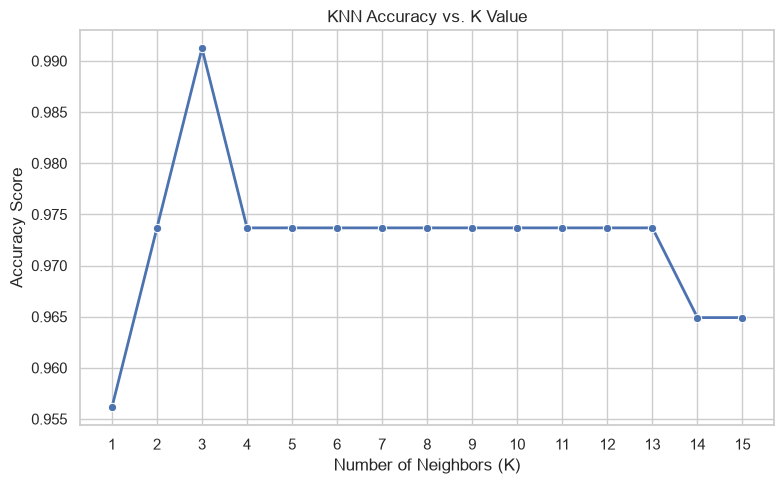

In [4]:
# Evaluate model performance for k values ranging from 1 to 15
cv_scores = []
k_range = range(1, 16)

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    knn_cv.fit(X_train_scaled, y_train)
    
    acc = accuracy_score(y_test, knn_cv.predict(X_test_scaled))
    cv_scores.append(acc)

# Visualize the results
plt.figure(figsize=(8, 5))
sns.lineplot(x=k_range, y=cv_scores, marker="o", linewidth=2)
plt.xticks(k_range)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy Score")
plt.title("KNN Accuracy vs. K Value")
plt.tight_layout()
plt.show()

### **Key Revision Notes**

**The Bias-Variance Tradeoff in K:**
* **Very Low K (e.g., K=1):** The model is highly sensitive to local noise, leading to **Overfitting**.
* **Very High K:** The model over-generalizes and smooths out the decision boundaries too much, leading to **Underfitting**.

**Limitations of KNN:**
* **Lazy Learning:** KNN does not build a generalized internal model during training; instead, it stores the entire dataset and performs all distance computations at prediction time.
* **Computational Inefficiency:** Prediction becomes extremely slow for large datasets because it calculates the distance to every single training sample.
* **Curse of Dimensionality:** Model performance degrades significantly in high-dimensional feature spaces as distance metrics lose their separating meaning.
* **Sensitivity:** Highly susceptible to outliers and performs poorly on imbalanced datasets without adjustments.